In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [3]:
base = "/pscratch/sd/m/mpowell/SENSITIVITY_LES_CUMULUS"
kw   = dict(decode_times=False, combine='nested', concat_dim='rep')

ds_dom_3D  = xr.open_mfdataset(f"{base}/domain_experiment/rt/rep_*/qlqi_path.xy.nc",       **kw).sel(time = slice(17500, 50000))
ds_dom_1D  = xr.open_mfdataset(f"{base}/domain_experiment/standard/rep_*/qlqi_path.xy.nc", **kw).sel(time = slice(17500, 50000))
ds_seed_3D = xr.open_mfdataset(f"{base}/seed_experiment/rt/seed_*/qlqi_path.xy.nc",        **kw).sel(time = slice(17500, 50000))
ds_seed_1D = xr.open_mfdataset(f"{base}/seed_experiment/standard/seed_*/qlqi_path.xy.nc",  **kw).sel(time = slice(17500, 50000))


In [4]:
CACHE_DOM_PIXELS  = f"{base}/cache/dom_diff_pixels.zarr"
CACHE_SEED_PIXELS = f"{base}/cache/seed_diff_pixels.zarr"

if os.path.exists(CACHE_DOM_PIXELS) and os.path.exists(CACHE_SEED_PIXELS):
    dom_diff_pixels = xr.open_zarr(CACHE_DOM_PIXELS, decode_times=False)['dom_diff_pixels']
    seed_diff_full  = xr.open_zarr(CACHE_SEED_PIXELS, decode_times=False)['seed_diff_full']
    print(f"Loaded from cache: {CACHE_DOM_PIXELS}, {CACHE_SEED_PIXELS}")
else:
    dom_diff_pixels = (ds_dom_3D['qlqi_path'] - ds_dom_1D['qlqi_path']).load()
    seed_diff_full  = (ds_seed_3D['qlqi_path'] - ds_seed_1D['qlqi_path']).load()
    os.makedirs(os.path.dirname(CACHE_DOM_PIXELS),  exist_ok=True)
    os.makedirs(os.path.dirname(CACHE_SEED_PIXELS), exist_ok=True)
    xr.Dataset({'dom_diff_pixels':  dom_diff_pixels}).to_zarr(CACHE_DOM_PIXELS)
    xr.Dataset({'seed_diff_full':   seed_diff_full }).to_zarr(CACHE_SEED_PIXELS)
    print(f"Computed and cached to: {CACHE_DOM_PIXELS}, {CACHE_SEED_PIXELS}")

seed_diff_pixels = seed_diff_full.isel(rep=0)   # always derived, no need to cache

Loaded from cache: /pscratch/sd/m/mpowell/SENSITIVITY_LES_CUMULUS/cache/dom_diff_pixels.zarr, /pscratch/sd/m/mpowell/SENSITIVITY_LES_CUMULUS/cache/seed_diff_pixels.zarr


In [6]:
seed_diff_pixels

<xarray.DataArray 'seed_diff_full' (time: 542, y: 512, x: 512)> Size: 1GB
dask.array<getitem, shape=(542, 512, 512), dtype=float64, chunksize=(68, 64, 128), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 4kB 25.0 75.0 125.0 ... 2.548e+04 2.552e+04 2.558e+04
  * time     (time) float64 4kB 1.752e+04 1.758e+04 ... 4.992e+04 4.998e+04
  * x        (x) float64 4kB 25.0 75.0 125.0 ... 2.548e+04 2.552e+04 2.558e+04

In [7]:
dom_diff_pixels

<xarray.DataArray 'dom_diff_pixels' (rep: 16, time: 542, y: 128, x: 128)> Size: 1GB
dask.array<open_dataset-dom_diff_pixels, shape=(16, 542, 128, 128), dtype=float64, chunksize=(2, 136, 32, 32), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float64 4kB 1.752e+04 1.758e+04 ... 4.992e+04 4.998e+04
  * x        (x) float64 1kB 25.0 75.0 125.0 ... 6.275e+03 6.325e+03 6.375e+03
  * y        (y) float64 1kB 25.0 75.0 125.0 ... 6.275e+03 6.325e+03 6.375e+03
Dimensions without coordinates: rep

In [5]:
spatial_dims_dom  = ['rep', 'x', 'y']
spatial_dims_seed = ['x', 'y']

# Mean and std over space/reps at each time step
dom_mean  = dom_diff_pixels.mean(dim=spatial_dims_dom)
dom_std   = dom_diff_pixels.std( dim=spatial_dims_dom)
seed_mean = seed_diff_pixels.mean(dim=spatial_dims_seed)
seed_std  = seed_diff_pixels.std( dim=spatial_dims_seed)

# mean / std  
dom_d  = dom_mean  / dom_std
seed_d = seed_mean / seed_std

In [9]:
# Collapse spatial dims first — domain-average 3D-1D diff per rep per time step
# std across reps is now sampling uncertainty of the domain-mean signal, not cloud patchiness
dom_avg_diff  = dom_diff_pixels.mean(dim=['x', 'y'])   # [rep, time]
seed_avg_diff = seed_diff_full.mean(dim=['x', 'y'])    # [rep, time]

Small-domain reps: 16   |   Large-domain tiles: 16  (4×4)


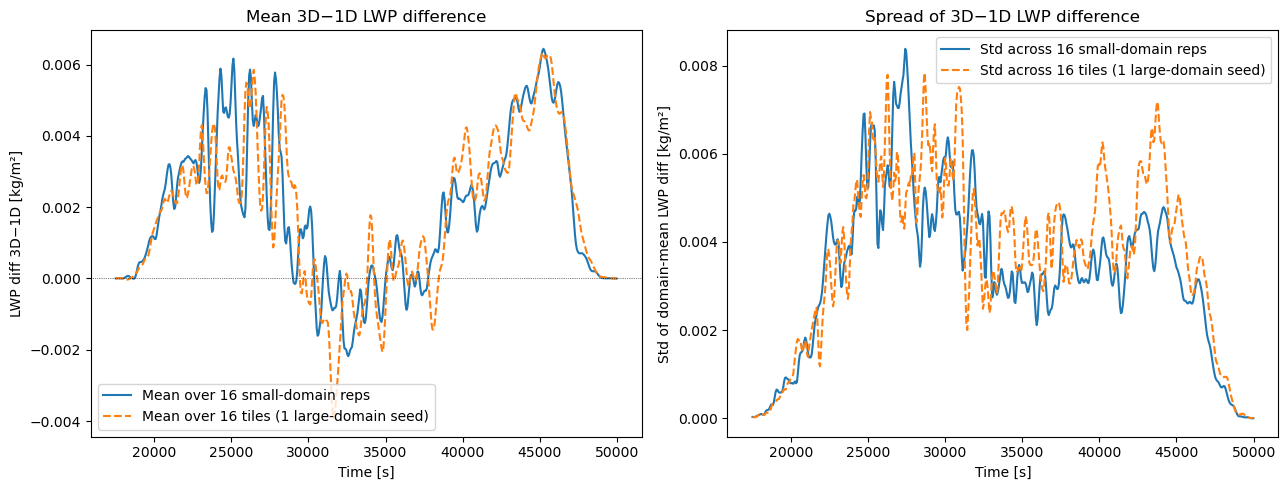

/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/dask/_task_spec.py:7

In [ ]:
nx_dom = dom_diff_pixels.sizes['x']
ny_dom = dom_diff_pixels.sizes['y']

# seed_diff_full: (rep, time, x, y) — pick one seed, coarsen to tile means
seed_tile_diff = (
    seed_diff_full
    .isel(rep=0)                                    # (time, x, y)
    .coarsen(x=nx_dom, y=ny_dom, boundary='trim')
    .mean()                                         # (time, x_tile, y_tile)
    .stack(tile=('x', 'y'))                         # (time, tile)
)

n_tiles = seed_tile_diff.sizes['tile']
n_reps  = dom_avg_diff.sizes['rep']
print(f"Small-domain reps: {n_reps}   |   Large-domain tiles: {n_tiles}  ({int(n_tiles**0.5)}×{int(n_tiles**0.5)})")

# Domain-mean per rep/tile, then spread across that ensemble
dom_mean_reps   = dom_avg_diff.mean('rep')
dom_std_reps    = dom_avg_diff.std('rep')

seed_mean_tiles = seed_tile_diff.mean('tile')
seed_std_tiles  = seed_tile_diff.std('tile')

time = dom_avg_diff.time.values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(time, dom_mean_reps.values,
        label=f'Mean over {n_reps} small-domain reps')
ax.plot(time, seed_mean_tiles.values, ls='--',
        label=f'Mean over {n_tiles} tiles (1 large-domain seed)')
ax.axhline(0, color='k', ls=':', lw=0.5)
ax.set(xlabel='Time [s]', ylabel='LWP diff 3D−1D [kg/m²]',
       title='Mean 3D−1D LWP difference')
ax.legend()

ax = axes[1]
ax.plot(time, dom_std_reps.values,
        label=f'Std across {n_reps} small-domain reps')
ax.plot(time, seed_std_tiles.values, ls='--',
        label=f'Std across {n_tiles} tiles (1 large-domain seed)')
ax.set(xlabel='Time [s]', ylabel='Std of domain-mean LWP diff [kg/m²]',
       title='Spread of 3D−1D LWP difference')
ax.legend()

plt.tight_layout()

In this plot we attempt to answer the question, are many smaller domain runs equivalent to one large domain run for the signal-to-noise of the LWP change for 3D vs. 1D treatments of radiation.

In the single large domain run, we an x and y domain of 25.6 km, run with 3D and 1D treatments of radiation.

In the 16 small domain runs, we have an x and y domain of 6.4 km (1/16th of the total size). Each 1D and 3D run is initialized with a different random seed.

Comparing the mean and standard devation of domain-mean LWP (we tile the large domain into 16 tiles to obtain this), we see they are similar in magnitude, suggesting spatially stationary turbulence. If there was meso-scale organization and clustering, we would expect the standard deviation of the large domain to be smaller than the small domain reps. In fact, it is often slightly larger.

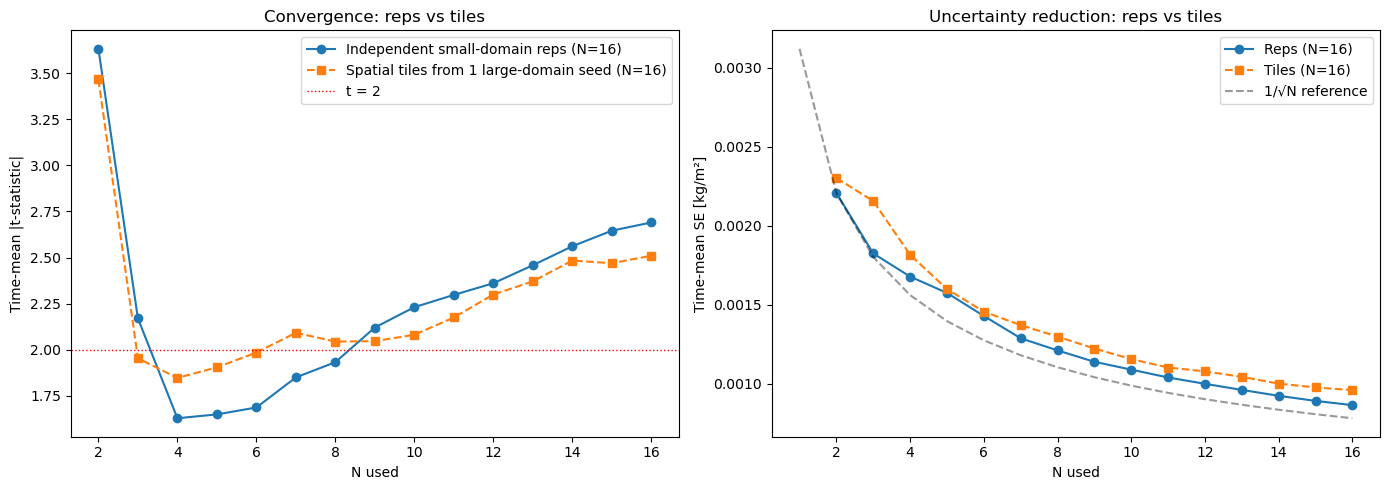

In [11]:
# Treat tiles as pseudo-reps and compare convergence rate of the t-statistic
# to that of truly independent small-domain reps.
# If tiles were independent, the curves would overlap.
# Spatial correlation among tiles → slower convergence than reps.

da_tiles_2d = seed_tile_diff.transpose('tile', 'time')  # (tile, time)
da_reps_2d  = dom_avg_diff                               # (rep,  time)

def tstat_convergence(da, sample_dim):
    n_total = da.sizes[sample_dim]
    means, ses, tstats = [], [], []
    for n in range(1, n_total + 1):
        sub  = da.isel({sample_dim: slice(0, n)})
        mean = sub.mean(dim=sample_dim)
        std  = sub.std( dim=sample_dim, ddof=1)   # NaN at n=1
        se   = std / np.sqrt(n)
        means.append(mean)
        ses.append(se)
        tstats.append(mean / se)
    return means, ses, tstats

mean_tiles, se_tiles, t_tiles = tstat_convergence(da_tiles_2d, 'tile')
mean_reps,  se_reps,  t_reps  = tstat_convergence(da_reps_2d,  'rep')

n_r = da_reps_2d.sizes['rep']
n_t = da_tiles_2d.sizes['tile']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: time-mean |t| vs N
ax = axes[0]
ax.plot(range(1, n_r + 1), [float(np.abs(t).mean()) for t in t_reps],
        'o-',  label=f'Independent small-domain reps (N={n_r})')
ax.plot(range(1, n_t + 1), [float(np.abs(t).mean()) for t in t_tiles],
        's--', label=f'Spatial tiles from 1 large-domain seed (N={n_t})')
ax.axhline(2, color='r', ls=':', lw=1, label='t = 2')
ax.set(xlabel='N used', ylabel='Time-mean |t-statistic|',
       title='Convergence: reps vs tiles')
ax.legend()
# (spatial correlation → tiles converge slower)

# Panel 2: time-averaged SE vs N
ax = axes[1]
ax.plot(range(1, n_r + 1), [float(se.mean()) for se in se_reps],
        'o-',  label=f'Reps (N={n_r})')
ax.plot(range(1, n_t + 1), [float(se.mean()) for se in se_tiles],
        's--', label=f'Tiles (N={n_t})')
# 1/sqrt(N) reference anchored at N=2
se2 = float(se_reps[1].mean())
ns  = np.arange(1, max(n_r, n_t) + 1)
ax.plot(ns, se2 * np.sqrt(2) / np.sqrt(ns), 'k--', alpha=0.4, label='1/√N reference')
ax.set(xlabel='N used', ylabel='Time-mean SE [kg/m²]',
       title='Uncertainty reduction: reps vs tiles')
ax.legend()

plt.tight_layout()


In this next plot we test whether the small domain runs and the tiled, single large domain runs coverge similarly. First, we plot the time-averaged t-statistic with increasing N samples. This can be thought of as an estimate of the signal to noise ratio (STN). For 2 to 4 samples, we see STN is unstable, decreasing from 2 to 3 samples. With N=2, the t-statistic is inflated because we're dividing by a standard error estimated from just 1 degree of freedom. The variance estimate is extremely noisy and biased low by chance here, making t artificially large. When we add a 3rd and 4th sample, we get a more realistic (and usually larger) variance estimate, which deflates the t-statistic. The fact that both methods show the same behavior confirms this is a small-sample statistical artifact, not something physical.

From 4 to 16 samples we see a flattening increase that scales like sqrt(N). From 10 samples onwards, the STN is greater than 2 through the full time series of the LES simulations. Next we look at how uncertainity reduces with increasing samples, using the time-mean standard error. This closely follows the 1/sqrt(N) that is plotted as has started to level out by 16 samples.

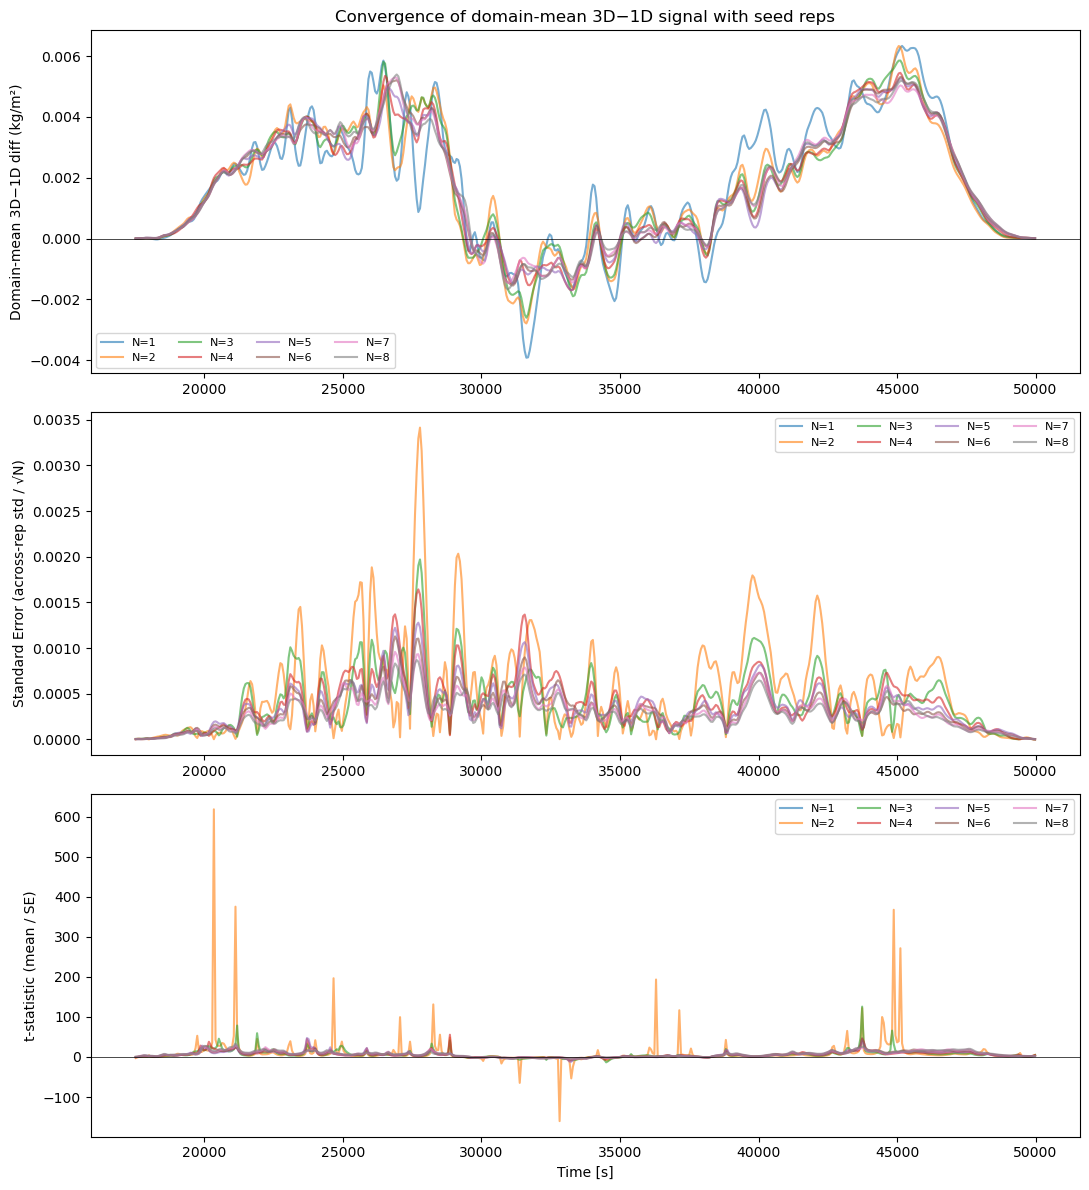

In [13]:
# Convergence: std is now across-rep variability of domain averages (not pixel patchiness)
n_reps_total = seed_avg_diff.sizes['rep']
d_list_avg, se_list_avg, mean_list_avg = [], [], []

for n in range(1, n_reps_total + 1):
    diff_n = seed_avg_diff.isel(rep=slice(0, n))
    mean_t = diff_n.mean(dim='rep')
    std_t  = diff_n.std( dim='rep', ddof=1)   # NaN for n=1, that's fine
    se_t   = std_t / np.sqrt(n)
    d_list_avg.append(mean_t / se_t)
    se_list_avg.append(se_t)
    mean_list_avg.append(mean_t)

time_mean_d_avg  = [float(np.abs(d).mean()) for d in d_list_avg]
time_mean_se_avg = [float(se.mean())        for se in se_list_avg]

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=False)

for n, mean in enumerate(mean_list_avg, start=1):
    axes[0].plot(mean.time, mean, alpha=0.6, label=f'N={n}')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].legend(ncol=4, fontsize=8)
axes[0].set_ylabel('Domain-mean 3D−1D diff (kg/m²)')
axes[0].set_title('Convergence of domain-mean 3D−1D signal with seed reps')

for n, se in enumerate(se_list_avg, start=1):
    axes[1].plot(se.time, se, alpha=0.6, label=f'N={n}')
axes[1].legend(ncol=4, fontsize=8)
axes[1].set_ylabel('Standard Error (across-rep std / √N)')

for n, d in enumerate(d_list_avg, start=1):
    axes[2].plot(d.time, d, alpha=0.6, label=f'N={n}')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_ylabel('t-statistic (mean / SE)')
axes[2].set_xlabel('Time [s]')
axes[2].legend(ncol=4, fontsize=8)

plt.tight_layout()


To be super robust, we actually look at 1 up to 8 replicates of the large domain. Here the domain-mean change in LWP is plotted for increasing numbers of samples, becoming smoother from 1 to 8. The standard error also dramatically decreases with N, from spikes as large as 0.0035 kg/m2 for N = 2 to smooth values less than 0.001 kg/m2 for N = 8. The t-statistic is noisy through time, especially for N = 2, so we will look at time-averaged values.

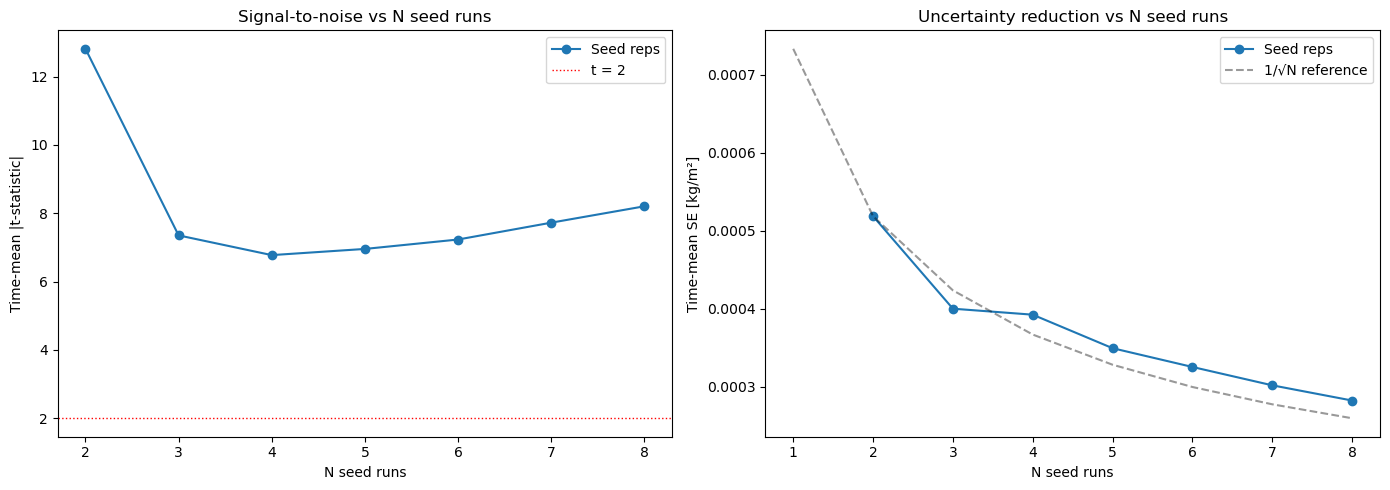

In [14]:

# ── Seed convergence summary: SNR + uncertainty reduction ────────────────────
# Mirrors the domain/tile comparison figure (qa10zql02f) for seed reps.

ns = np.arange(1, n_reps_total + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: time-mean |t| vs N  (moved from the detail figure above)
ax = axes[0]
ax.plot(ns, time_mean_d_avg, 'o-', label='Seed reps')
ax.axhline(2, color='r', ls=':', lw=1, label='t = 2')
ax.set(xlabel='N seed runs', ylabel='Time-mean |t-statistic|',
       title='Signal-to-noise vs N seed runs')
ax.legend()

# Panel 2: time-mean SE vs N (uncertainty reduction)
ax = axes[1]
ax.plot(ns, time_mean_se_avg, 'o-', label='Seed reps')
se2 = time_mean_se_avg[1]   # anchor 1/√N at N=2
ax.plot(ns, se2 * np.sqrt(2) / np.sqrt(ns), 'k--', alpha=0.4, label='1/√N reference')
ax.set(xlabel='N seed runs', ylabel='Time-mean SE [kg/m²]',
       title='Uncertainty reduction vs N seed runs')
ax.legend()

plt.tight_layout()


For all replicates, the STN is robust. Ignoring N = 2-3 due to statistical noise, from N=4 onwards, STN is 8 or greater. The standard deviation across a larger domain is smaller than that for the small domains, so STN here is higher. Uncertainty once again decreases like sqrt(N). I am considering using one large domain experiment, perhaps increasing the domain size to that largest that fits on the GPU instead of smaller replicates.